## Puffin GRO-CAP signal analysis

This section evaluates whether CTCF-free boundary-optimized sequences show changes in predicted transcriptional activity compared to the original genomic sequences.

### Motivation
Boundary elements in the genome are often associated with CTCF binding, which can also influence local transcription. By designing sequences that fold into boundaries **without** CTCF motifs, we ask: do these sequences nonetheless alter predicted transcription, or is the boundary fold achieved through a transcriptionally neutral mechanism?

### Data
PuffinD predictions were generated for **100 kb windows** centered on the edited bin, for each successfully optimized sequence and its corresponding original. The central 2,048 bp (one Akita bin) was replaced by the optimized sequence; flanking regions were kept identical to the reference genome (mm10). GRO-CAP signal is extracted from PuffinD output channels 3 (forward strand) and 6 (reverse strand), trimmed to the central edited bin.

Successful optimizations are defined as sequences where:
- Insulation score difference < −0.005 (non-trivial boundary formation)
- No CTCF motifs detected by FIMO (MA0139.1, p < 1e-4)

### Analyses and figures

1. **ECDF of max GRO-CAP signal** — compares the distribution of maximum predicted GRO-CAP signal (across both strands) before and after optimization, against a baseline of ~50k mouse TSSs. Indicates whether optimized sequences approach TSS-like transcriptional activity.

2. **Percentile analysis** — each optimized sequence's max GRO-CAP signal is placed within the mouse TSS distribution to quantify how transcriptionally active the optimized sequences are relative to real gene promoters.

3. **Signal tracks** — per-sequence GRO-CAP signal profiles before (solid) and after (dashed) optimization for a representative subset of windows. Forward strand shown above zero (blue), reverse strand mirrored below zero (red).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, wilcoxon
from pathlib import Path

In [2]:
PUFFIN_BASE   = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/results")
PUFFIN_ORIG   = PUFFIN_BASE / "puffin_original"
PUFFIN_OPT    = PUFFIN_BASE / "puffin_optimized"
SUCCESS_TSV   = PUFFIN_BASE / "successful_optimization.tsv"
TSS_TSV = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/puffin_mouse_TSSs/tss_gro_cap_max_signal.tsv")
PLOTS_DIR = Path("./../plots/")

BIN_SIZE         = 2048

FLANK         = (100_000 - BIN_SIZE) // 2   # same as in FASTA saving step

In [3]:
# Load successful optimizations
success_df = pd.read_csv(SUCCESS_TSV, sep="\t")

## Read puffin predictions

In [4]:
max_before        = []
max_after         = []

mean_diffs_f      = []
max_diffs_f       = []
mean_signed_diffs_f = []
max_signed_diffs_f  = []
correlations_f    = []
all_diffs_f       = []
pvals_f           = []

mean_diffs_r      = []
max_diffs_r       = []
mean_signed_diffs_r = []
max_signed_diffs_r  = []
correlations_r    = []
all_diffs_r       = []
pvals_r           = []

for _, row in success_df.iterrows():
    chrom          = row["chrom"]
    centered_start = int(row["centered_start"])
    centered_end   = int(row["centered_end"])
    stem           = f"{chrom}_{centered_start}_{centered_end}"

    orig = np.load(PUFFIN_ORIG / f"{stem}_original.npy")
    orig_f = orig[0, 3, FLANK:-FLANK]
    orig_r = orig[0, 6, FLANK:-FLANK]

    opt = np.load(PUFFIN_OPT / f"{stem}_optimized.npy")
    opt_f = opt[0, 3, FLANK:-FLANK]
    opt_r = opt[0, 6, FLANK:-FLANK]

    max_before.append(max(np.max(orig_f), np.max(orig_r)))
    max_after.append(max(np.max(opt_f),  np.max(opt_r)))

    # Forward strand
    diff_f = opt_f - orig_f
    all_diffs_f.append(diff_f)
    mean_diffs_f.append(np.mean(np.abs(diff_f)))
    max_diffs_f.append(np.max(np.abs(diff_f)))
    mean_signed_diffs_f.append(np.mean(diff_f))
    max_signed_diffs_f.append(np.max(diff_f))
    correlations_f.append(pearsonr(orig_f, opt_f)[0])
    _, pval_f = wilcoxon(orig_f, opt_f)
    pvals_f.append(pval_f)

    # Reverse strand
    diff_r = opt_r - orig_r
    all_diffs_r.append(diff_r)
    mean_diffs_r.append(np.mean(np.abs(diff_r)))
    max_diffs_r.append(np.max(np.abs(diff_r)))
    mean_signed_diffs_r.append(np.mean(diff_r))
    max_signed_diffs_r.append(np.max(diff_r))
    correlations_r.append(pearsonr(orig_r, opt_r)[0])
    _, pval_r = wilcoxon(orig_r, opt_r)
    pvals_r.append(pval_r)

# ── Attach results to dataframe ───────────────────────────────────────────────
success_df = success_df.assign(
    max_before          = max_before,
    max_after           = max_after,
    mean_diff_f         = mean_diffs_f,
    max_diff_f          = max_diffs_f,
    mean_signed_diff_f  = mean_signed_diffs_f,
    max_signed_diff_f   = max_signed_diffs_f,
    corr_f              = correlations_f,
    pval_f              = pvals_f,
    mean_diff_r         = mean_diffs_r,
    max_diff_r          = max_diffs_r,
    mean_signed_diff_r  = mean_signed_diffs_r,
    max_signed_diff_r   = max_signed_diffs_r,
    corr_r              = correlations_r,
    pval_r              = pvals_r,
)

print(f"Loaded puffin predictions for {len(success_df)} sequences")


Loaded puffin predictions for 178 sequences


## Stats

In [5]:
stats = (
    success_df[["max_before", "max_after"]]
    .rename(columns={"max_before": "Before", "max_after": "After"})
    .describe()
    .loc[["min", "25%", "50%", "mean", "75%", "max"]]
)
stats.index = ["Min", "25th percentile", "Median", "Mean", "75th percentile", "Max"]
print("Max GRO-CAP signal — Before vs After optimization")
print(stats.to_string(float_format="{:.4f}".format))

Max GRO-CAP signal — Before vs After optimization
                 Before  After
Min              0.0001 0.0002
25th percentile  0.0006 0.0022
Median           0.0016 0.0119
Mean             0.0194 0.2658
75th percentile  0.0052 0.2129
Max              1.1724 2.0517


## ECDF plot

In [6]:
# GRO-cap predictions for 51k mouse TSSs
tss_df  = pd.read_csv(TSS_TSV, sep="\t")

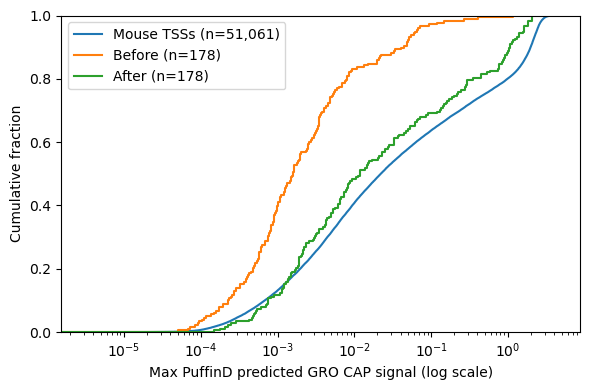

In [7]:
# ── ECDF plot ─────────────────────────────────────────────────────────────────
n = len(success_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.ecdfplot(tss_df["max_signal"],     label=f"Mouse TSSs (n={len(tss_df):,})", ax=ax)
sns.ecdfplot(success_df["max_before"], label=f"Before (n={n})", ax=ax)
sns.ecdfplot(success_df["max_after"],  label=f"After (n={n})",  ax=ax)

ax.set_xscale("log")
ax.set_xlabel("Max PuffinD predicted GRO CAP signal (log scale)")
ax.set_ylabel("Cumulative fraction")
ax.legend()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / "puffin_ecdf.svg", format="svg")
plt.show()

## Percentiles of optimized signal within TSS distribution

In [8]:
tss_max = tss_df["max_signal"].values
percentiles_before = [np.mean(tss_max <= x) for x in success_df["max_before"]]
percentiles_after  = [np.mean(tss_max <= x) for x in success_df["max_after"]]

print(f"Median percentile (before) within TSS distribution : {np.median(percentiles_before):.3f}")
print(f"Median percentile (after)  within TSS distribution : {np.median(percentiles_after):.3f}")

Median percentile (before) within TSS distribution : 0.177
Median percentile (after)  within TSS distribution : 0.430


## Puffin signal tracks for 5 example sequences

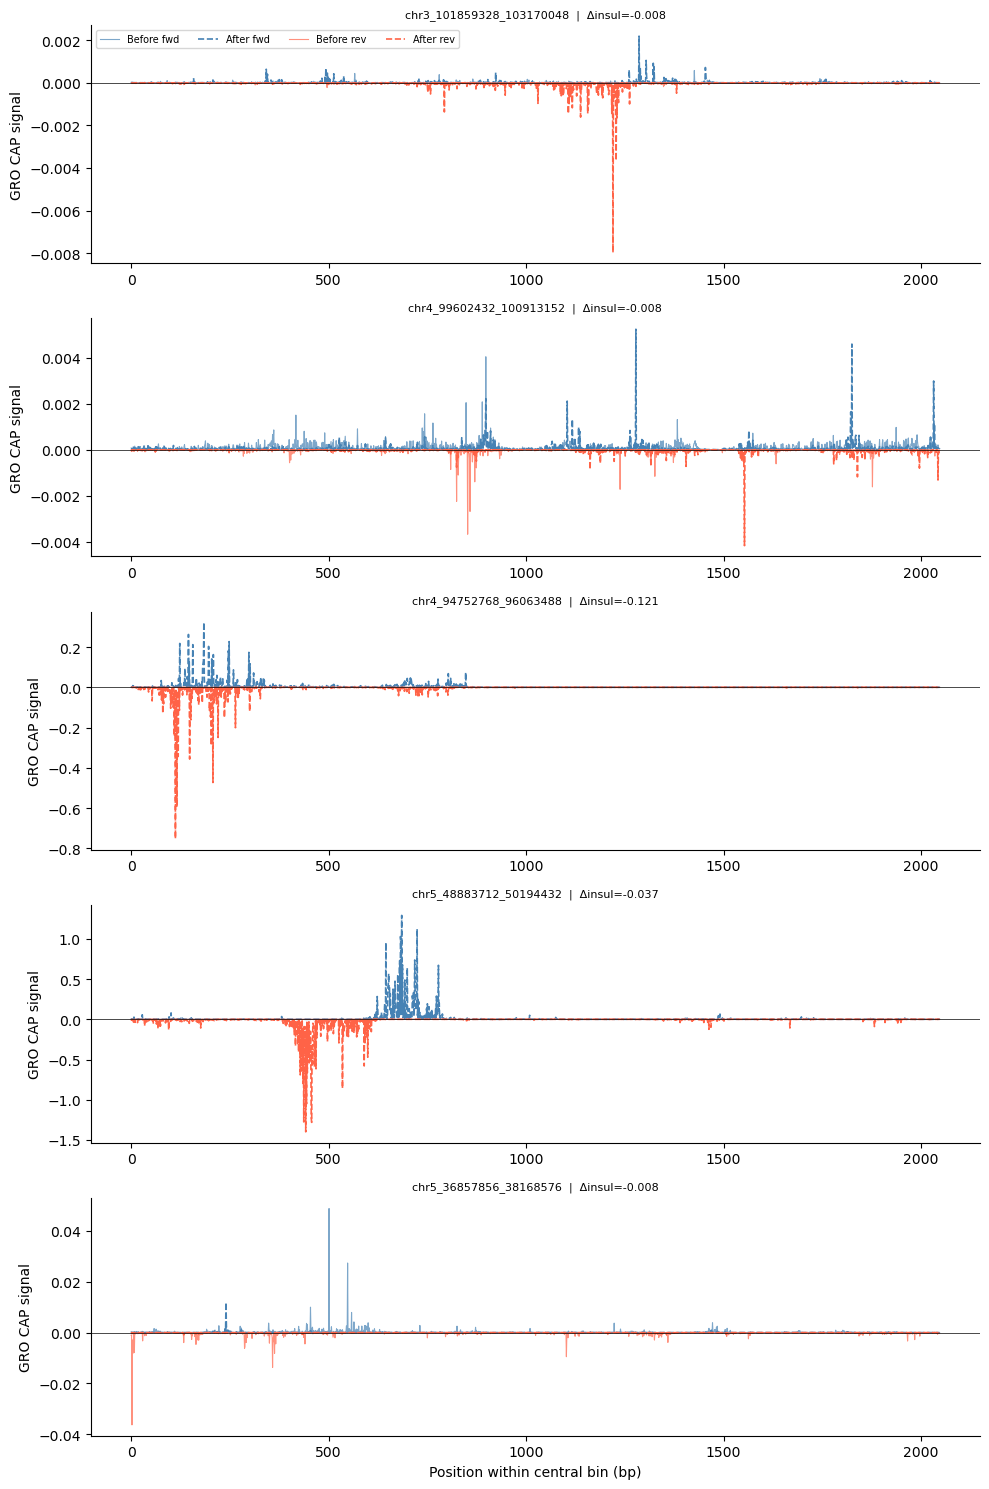

In [9]:
N_TRACKS   = 5
track_rows = success_df.head(N_TRACKS)
positions  = np.arange(BIN_SIZE)   # x-axis: positions within central bin

fig, axes = plt.subplots(N_TRACKS, 1, figsize=(10, 3 * N_TRACKS), squeeze=False)

for idx, (_, row) in enumerate(track_rows.iterrows()):
    chrom          = row["chrom"]
    centered_start = int(row["centered_start"])
    centered_end   = int(row["centered_end"])
    stem           = f"{chrom}_{centered_start}_{centered_end}"

    orig = np.load(PUFFIN_ORIG / f"{stem}_original.npy")
    opt  = np.load(PUFFIN_OPT  / f"{stem}_optimized.npy")

    # Central bin only (remove flanks, then slice central BIN_SIZE bp)
    orig_f = orig[0, 3, FLANK : FLANK + BIN_SIZE]
    orig_r = orig[0, 6, FLANK : FLANK + BIN_SIZE]
    opt_f  = opt[0,  3, FLANK : FLANK + BIN_SIZE]
    opt_r  = opt[0,  6, FLANK : FLANK + BIN_SIZE]

    ax = axes[idx][0]
    ax.plot(positions, orig_f,  color="steelblue",  alpha=0.7, linewidth=0.8, label="Before fwd")
    ax.plot(positions, opt_f,   color="steelblue",  alpha=1.0, linewidth=1.2, linestyle="--", label="After fwd")
    ax.plot(positions, -orig_r, color="tomato",     alpha=0.7, linewidth=0.8, label="Before rev")
    ax.plot(positions, -opt_r,  color="tomato",     alpha=1.0, linewidth=1.2, linestyle="--", label="After rev")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"{stem}  |  Δinsul={row['insul_score_diff']:.3f}", fontsize=8)
    ax.set_ylabel("GRO CAP signal")
    if idx == 0:
        ax.legend(fontsize=7, ncol=4)

axes[-1][0].set_xlabel("Position within central bin (bp)")
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / "puffin_signal_tracks.pdf", bbox_inches="tight")
plt.show()